# Phase 2 — Descripteurs RDKit + modèle QSAR (ERBB2/HER2)

À partir des molécules récupérées dans `01_bioactivity_data_acquisition.ipynb`, on calcule des descripteurs moléculaires avec RDKit, puis on entraîne un modèle XGBoost qui prédit si une molécule sera **active** sur ERBB2 à partir de sa seule structure chimique (SMILES). Même logique que le pipeline OncoPrint (XGBoost + SHAP), appliquée à une autre matière première.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

df = pd.read_csv("../data/raw/erbb2_activities.csv")
df.shape

(1070, 7)

## 1. Calcul des descripteurs moléculaires

Descripteurs de Lipinski (règle des 5, "druggabilité") + quelques descripteurs physico-chimiques complémentaires.

In [2]:
def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "molecular_weight": Descriptors.MolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "h_bond_donors": Lipinski.NumHDonors(mol),
        "h_bond_acceptors": Lipinski.NumHAcceptors(mol),
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol),
        "tpsa": Descriptors.TPSA(mol),
        "aromatic_rings": Descriptors.NumAromaticRings(mol),
        "ring_count": Descriptors.RingCount(mol),
        "heavy_atoms": Descriptors.HeavyAtomCount(mol),
        "molar_refractivity": Descriptors.MolMR(mol),
    }

descriptors = df["canonical_smiles"].apply(compute_descriptors)
descriptors_df = pd.DataFrame(descriptors.tolist())

# On ne dropna que sur les descripteurs : activity_value_um/pactivity sont
# absents pour les essais qualitatifs (actif/inactif sans valeur chiffrée),
# les garder évite de biaiser le jeu de données vers les seuls essais dose-réponse.
data = pd.concat([df.reset_index(drop=True), descriptors_df], axis=1).dropna(subset=list(descriptors_df.columns))
data.shape

(1070, 17)

## 2. Règle de Lipinski (druggabilité) — indicatif, pas un filtre

In [3]:
data["lipinski_violations"] = (
    (data["molecular_weight"] > 500).astype(int)
    + (data["logp"] > 5).astype(int)
    + (data["h_bond_donors"] > 5).astype(int)
    + (data["h_bond_acceptors"] > 10).astype(int)
)
data["lipinski_violations"].value_counts().sort_index()

lipinski_violations
0    492
1    318
2    260
Name: count, dtype: int64

## 3. Modèle QSAR : prédire l'activité à partir des descripteurs

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

feature_cols = [
    "molecular_weight", "logp", "h_bond_donors", "h_bond_acceptors",
    "rotatable_bonds", "tpsa", "aromatic_rings", "ring_count",
    "heavy_atoms", "molar_refractivity", "lipinski_violations",
]
X = data[feature_cols]
y = data["active"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    eval_metric="logloss", random_state=42,
)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
print("ROC AUC :", roc_auc_score(y_test, proba))
print(classification_report(y_test, model.predict(X_test)))

ROC AUC : 0.9755351681957187
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       105
           1       0.96      0.88      0.92       109

    accuracy                           0.92       214
   macro avg       0.92      0.92      0.92       214
weighted avg       0.92      0.92      0.92       214



## 4. Interprétabilité SHAP

Quels descripteurs pèsent le plus dans la prédiction d'activité — même lecture que sur OncoPrint, mais sur des variables chimiques plutôt que génomiques.

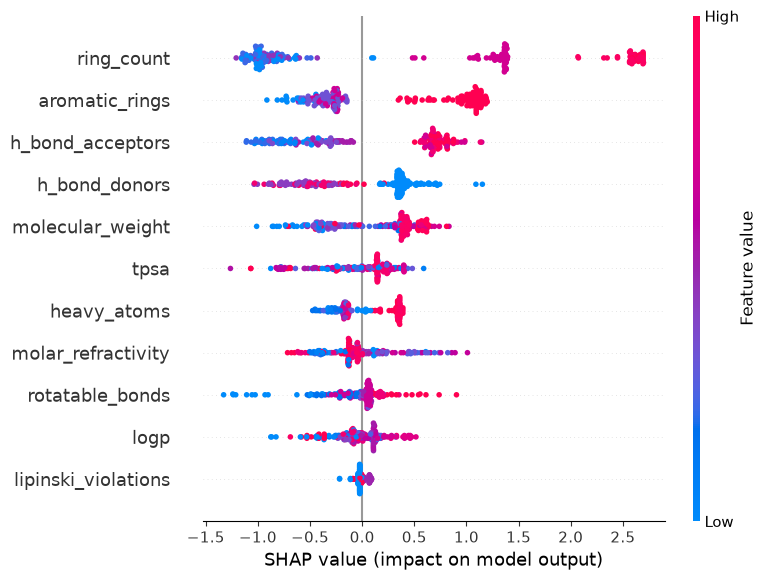

In [5]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## 5. Screening in silico d'une nouvelle molécule

Fonction utilitaire : on donne un SMILES, elle retourne une probabilité d'activité + le nombre de violations de Lipinski.

In [6]:
def screen_molecule(smiles, model=model, feature_cols=feature_cols):
    desc = compute_descriptors(smiles)
    if desc is None:
        return {"error": "SMILES invalide"}
    desc["lipinski_violations"] = (
        (desc["molecular_weight"] > 500)
        + (desc["logp"] > 5)
        + (desc["h_bond_donors"] > 5)
        + (desc["h_bond_acceptors"] > 10)
    )
    row = pd.DataFrame([desc])[feature_cols]
    proba = model.predict_proba(row)[0, 1]
    return {"activity_probability": round(float(proba), 3), "lipinski_violations": int(desc["lipinski_violations"])}

# Exemple : lapatinib (inhibiteur connu de HER2)
screen_molecule("CS(=O)(=O)CCNCc1oc(cc1)-c1ccc2ncnc(Nc3ccc(OCc4cccc(F)c4)c(Cl)c3)c2c1")

{'activity_probability': 0.676, 'lipinski_violations': 2}

In [7]:
import joblib
joblib.dump(model, "../models/qsar_erbb2_xgboost.pkl")
data.to_csv("../data/processed/erbb2_descriptors.csv", index=False)